# ***Projeto Concessão de Crédito (MLFLOW)***

***Objetivo***: *classificar clientes em relação à probabilidade de apresentarem inadimplência à concessão de
crédito*

## 1.0 Imports

### 1.1 Bibliotecas:

In [1]:
import pandas as pd
import numpy as np
import inflection
import pickle
from sklearn import model_selection as ms
from sklearn import impute as im
from sklearn import feature_selection as fs
from sklearn import ensemble as en
from sklearn import linear_model as lm
from sklearn import metrics as mt
from matplotlib import pyplot as plt

### 1.2 Carregando os dados:

In [2]:
df_raw = pd.read_csv('../datasets/train.csv', low_memory=False)

In [3]:
df_raw

,Unnamed: 0,target,TaxaDeUtilizacaoDeLinhasNaoGarantidas,Idade,NumeroDeVezes30-59DiasAtrasoNaoPior,TaxaDeEndividamento,RendaMensal,NumeroDeLinhasDeCreditoEEmprestimosAbertos,NumeroDeVezes90DiasAtraso,NumeroDeEmprestimosOuLinhasImobiliarias,NumeroDeVezes60-89DiasAtrasoNaoPior,NumeroDeDependentes
0,0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


## 2.0 Descrição dos dados:

In [3]:
df = df_raw.copy()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Unnamed: 0                                  150000 non-null  int64  
 1   target                                      150000 non-null  int64  
 2   TaxaDeUtilizacaoDeLinhasNaoGarantidas       150000 non-null  float64
 3   Idade                                       150000 non-null  int64  
 4   NumeroDeVezes30-59DiasAtrasoNaoPior         150000 non-null  int64  
 5   TaxaDeEndividamento                         150000 non-null  float64
 6   RendaMensal                                 120269 non-null  float64
 7   NumeroDeLinhasDeCreditoEEmprestimosAbertos  150000 non-null  int64  
 8   NumeroDeVezes90DiasAtraso                   150000 non-null  int64  
 9   NumeroDeEmprestimosOuLinhasImobiliarias     150000 non-null  int64  
 

In [4]:
# renomeando colunas:
cols_old = ['Unnamed: 0', 'target', 'TaxaDeUtilizacaoDeLinhasNaoGarantidas', 'Idade', 'NumeroDeVezes30-59DiasAtrasoNaoPior', 
           'TaxaDeEndividamento', 'RendaMensal', 'NumeroDeLinhasDeCreditoEEmprestimosAbertos', 'NumeroDeVezes90DiasAtraso', 
           'NumeroDeEmprestimosOuLinhasImobiliarias', 'NumeroDeVezes60-89DiasAtrasoNaoPior', 'NumeroDeDependentes']

snakecase = lambda x: inflection.underscore(x)

cols_new = list(map(snakecase, cols_old))

# rename
df.columns = cols_new

In [5]:
# checando NAs (nulos):
df.isna().sum()

unnamed: 0                                               0
target                                                   0
taxa_de_utilizacao_de_linhas_nao_garantidas              0
idade                                                    0
numero_de_vezes30_59_dias_atraso_nao_pior                0
taxa_de_endividamento                                    0
renda_mensal                                         29731
numero_de_linhas_de_credito_e_emprestimos_abertos        0
numero_de_vezes90_dias_atraso                            0
numero_de_emprestimos_ou_linhas_imobiliarias             0
numero_de_vezes60_89_dias_atraso_nao_pior                0
numero_de_dependentes                                 3924
dtype: int64

In [8]:
# verificando se há linhas duplicadas:
linhas_duplicadas = df[df.duplicated()]
print("Linhas duplicadas:")
print(linhas_duplicadas)

Linhas duplicadas:
Empty DataFrame
Columns: [unnamed: 0, target, taxa_de_utilizacao_de_linhas_nao_garantidas, idade, numero_de_vezes30_59_dias_atraso_nao_pior, taxa_de_endividamento, renda_mensal, numero_de_linhas_de_credito_e_emprestimos_abertos, numero_de_vezes90_dias_atraso, numero_de_emprestimos_ou_linhas_imobiliarias, numero_de_vezes60_89_dias_atraso_nao_pior, numero_de_dependentes]
Index: []


In [5]:
# eliminando coluna "unnamed"
df.drop('unnamed: 0', axis=1, inplace=True)

In [10]:
# estatística descritiva:
# atributos numéricos:
stat_desc = df.describe().T
stat_desc

,count,mean,std,min,25%,50%,75%,max
target,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
taxa_de_utilizacao_de_linhas_nao_garantidas,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
idade,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
numero_de_vezes30_59_dias_atraso_nao_pior,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
taxa_de_endividamento,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
renda_mensal,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
numero_de_linhas_de_credito_e_emprestimos_abertos,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
numero_de_vezes90_dias_atraso,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
numero_de_emprestimos_ou_linhas_imobiliarias,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
numero_de_vezes60_89_dias_atraso_nao_pior,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


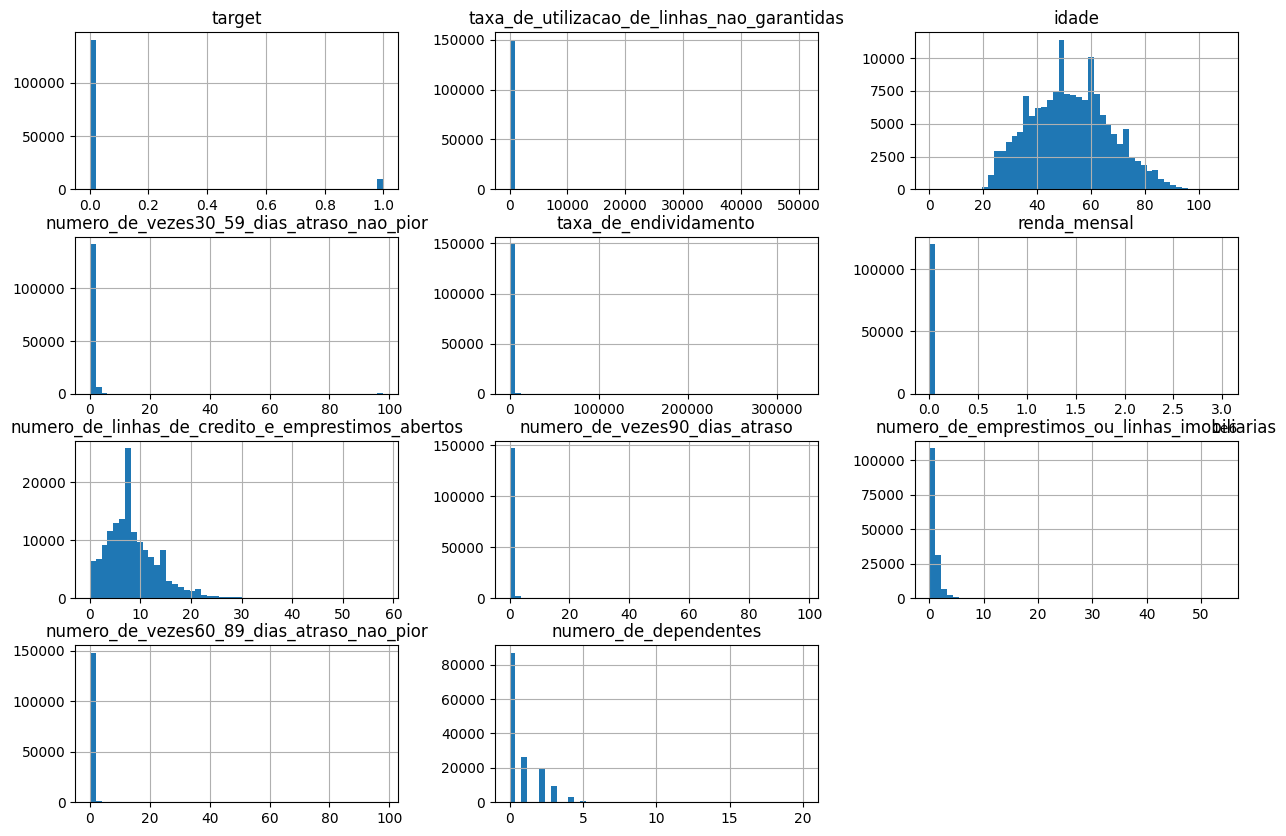

In [11]:
df.hist(bins=50, figsize=(15,10));

In [9]:
#verificando a variável 'target':
df['target'].value_counts(normalize=True)

target
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [ ]:
# conforme resultado acima, a classe 0 se refere aos adimplentes e a classe 1 se refere aos inadimplentes

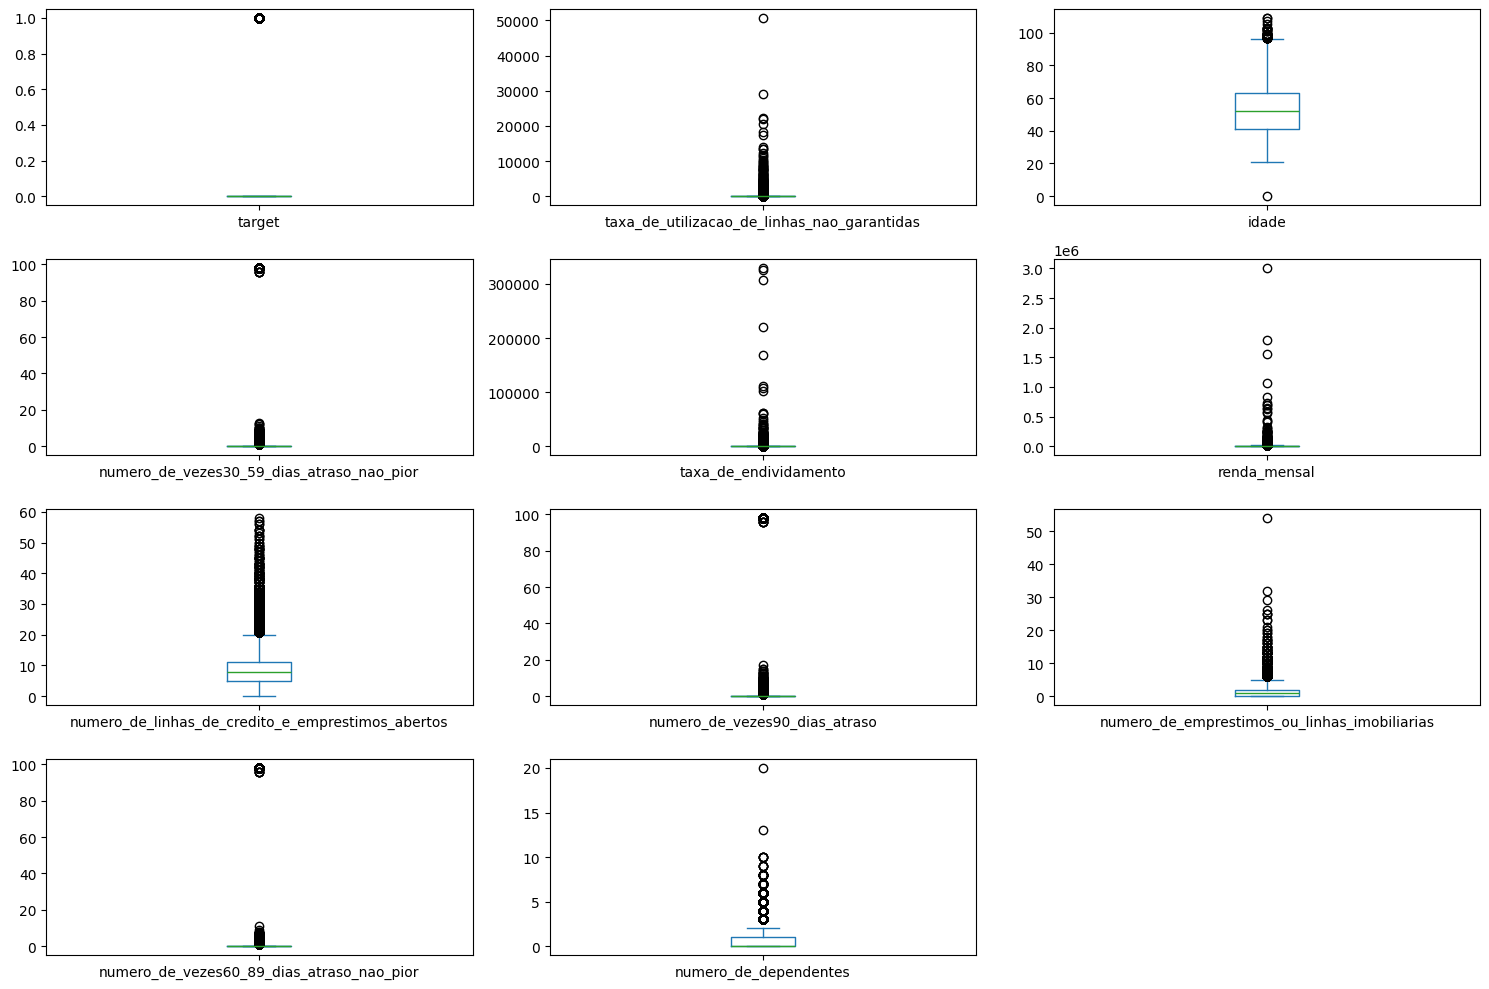

In [11]:
# boxplot das variáveis do dataframe:
df.plot(kind='box', subplots=True, layout=(4,3), figsize=(15,10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

## 3.0 Preparação dos dados

In [6]:
# separando os dados em treino e validação:
X = df.drop(['target'], axis=1)
y = df['target'] 

x_train, x_validation, y_train, y_validation = ms.train_test_split(X, y, test_size=0.20, stratify=y)

In [7]:
# tratando os elementos faltantes:
# inicialmente, fazendo uma substituição usando a mediana dos demais valores da coluna
# a escolha de strategy=median se deve ao fato dos dados apresentarem o que pode ser inicialmente entendido como outliers
impute = im.SimpleImputer(strategy='median')
cols_to_impute = ['renda_mensal', 'numero_de_dependentes']
impute.fit(x_train[cols_to_impute])

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [8]:
x_train[cols_to_impute] = impute.transform(x_train[cols_to_impute])
x_validation[cols_to_impute] = impute.transform(x_validation[cols_to_impute])

In [9]:
# seleção de features:

model = en.RandomForestClassifier(random_state=42, n_jobs=-1)
selector = fs.RFECV(estimator=model, cv=10, scoring='roc_auc')

selector.fit(x_train, y_train)
cols_selected = x_train.columns[selector.get_support()].tolist()

x_train_sel = x_train[cols_selected]

In [10]:
# comparação entre o número de features selecionadas e o número de colunas do dataframe:
print(selector.n_features_)
print(x_train.shape[1])

10
10


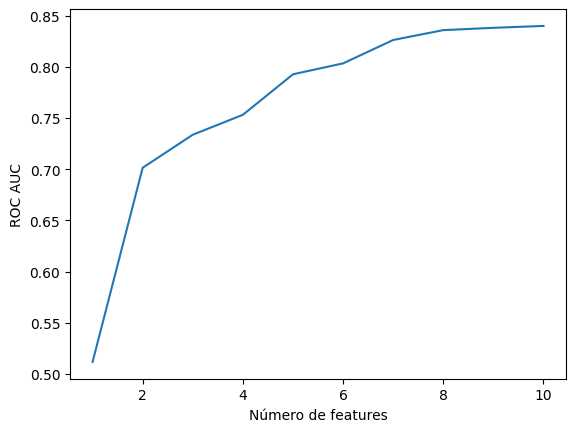

In [11]:
n_features = range(1, len(selector.cv_results_['mean_test_score']) + 1)

plt.plot(n_features, selector.cv_results_['mean_test_score'])
plt.xlabel('Número de features')
plt.ylabel('ROC AUC')
plt.show()

In [12]:
rf_model = selector.estimator_
importance = pd.Series(rf_model.feature_importances_, index=x_train.columns).sort_values(ascending=False)

print(importance)

taxa_de_utilizacao_de_linhas_nao_garantidas          0.194153
taxa_de_endividamento                                0.179380
renda_mensal                                         0.145090
idade                                                0.127915
numero_de_vezes90_dias_atraso                        0.092480
numero_de_linhas_de_credito_e_emprestimos_abertos    0.088765
numero_de_vezes30_59_dias_atraso_nao_pior            0.049257
numero_de_vezes60_89_dias_atraso_nao_pior            0.046421
numero_de_dependentes                                0.042083
numero_de_emprestimos_ou_linhas_imobiliarias         0.034456
dtype: float64


In [19]:
# A seleção de variáveis foi realizada utilizando o método RFECV (Recursive Feature Elimination with Cross-Validation), 
# com validação cruzada de 10 folds e métrica de avaliação roc_auc.
# O resultado indicou que o melhor desempenho do modelo foi obtido com todas as 10 features disponíveis, uma vez que 
# o número de features selecionadas foi igual ao número total de colunas do conjunto de treino.
# Esse comportamento sugere que todas as variáveis contribuem, ainda que em diferentes magnitudes, para a capacidade 
# preditiva do modelo, e que a remoção de qualquer uma delas levaria a uma redução, mesmo que pequena, na performance 
# média observada na validação cruzada.
# Para complementar a análise, foi avaliada a importância das features a partir do RandomForestClassifier. As 
# variáveis com maior contribuição para a predição foram:
# - taxa_de_utilizacao_de_linhas_nao_garantidas (~19%)
# - taxa_de_endividamento (~17%)
# - renda_mensal (~14%)
# - idade (~12%)
# Essas variáveis apresentam forte coerência com o contexto do problema, uma vez que indicadores de utilização de 
# crédito, nível de endividamento, renda e histórico financeiro são fatores tradicionalmente relevantes em modelos 
# de análise de risco e inadimplência.
# Além disso, variáveis relacionadas ao histórico de atrasos, como número de ocorrências de 90 dias ou mais, também 
# demonstraram importância significativa, reforçando seu valor preditivo.
# Mesmo as variáveis com menor importância relativa permaneceram acima de 3%, o que reforça a decisão do RFECV de 
# manter todas as features no modelo final.
# Assim, optei por seguir com o treinamento utilizando o conjunto completo de variáveis, priorizando a 
# maximização da performance preditiva.

## 4.0 Treinando o modelo

In [13]:
# aplicando nos dados de validação a mesma seleção de colunas dos dados de treino (feito na seção anterior):
x_validation_sel = x_validation[cols_selected]

In [14]:
lr = lm.LogisticRegression(max_iter=6000)
lr.fit(x_train_sel, y_train)
y_pred = lr.predict_proba(x_validation_sel)[:,1]

print(f'Score com todas as features: {mt.roc_auc_score(y_validation, y_pred)}')

Score com todas as features: 0.7050966974419639


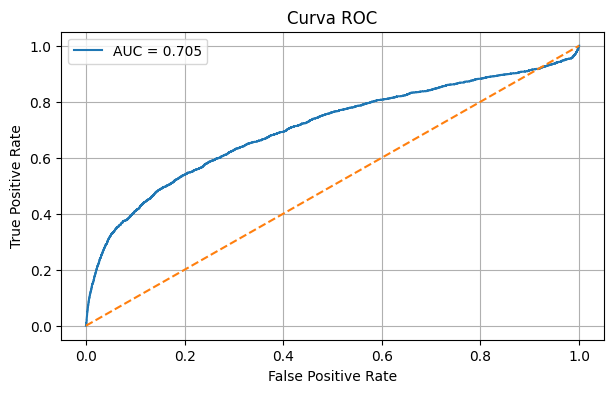

In [22]:
# curva roc:
fpr, tpr, thresholds = mt.roc_curve(y_validation, y_pred)
auc = mt.roc_auc_score(y_validation, y_pred)

plt.figure(figsize=(7,4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

## 5.0 Fine tuning (Tuning dos hiperparâmetros)

In [29]:
solvers = ['liblinear', 'lbfgs', 'newton-cg', 'sag', 'saga']
resultados = []

for solver in solvers:
    model = lm.LogisticRegression(solver=solver, random_state=42, max_iter=10000)
    
    auc_scores = ms.cross_val_score(model, x_train, y_train, cv=5, scoring='roc_auc')
    
    resultados.append({'solver': solver,
                       'mean_auc': auc_scores.mean(),
                       'std_auc': auc_scores.std()})

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by='mean_auc', ascending=False)

print(df_resultados)

      solver  mean_auc   std_auc
2  newton-cg  0.697108  0.006892
1      lbfgs  0.697106  0.006862
0  liblinear  0.691848  0.006631
3        sag  0.577506  0.007121
4       saga  0.576300  0.006746


## 6.0 Deploy do modelo

In [15]:
# concatenando os dados:
x_train_final = pd.concat([x_train, x_validation])
y_train_final = pd.concat([y_train, y_validation])

# treinando o modelo final com os dados treino+validação:
modelo_final = lm.LogisticRegression(solver='newton-cg', random_state=42, max_iter=10000)
modelo_final.fit(x_train_final, y_train_final)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [16]:
# fazendo 'ajustes' nos dados de teste:
df_raw_teste = pd.read_csv('../datasets/test.csv', low_memory=False)

cols_old = ['Unnamed: 0', 'TaxaDeUtilizacaoDeLinhasNaoGarantidas', 'Idade', 'NumeroDeVezes30-59DiasAtrasoNaoPior', 
           'TaxaDeEndividamento', 'RendaMensal', 'NumeroDeLinhasDeCreditoEEmprestimosAbertos', 'NumeroDeVezes90DiasAtraso', 
           'NumeroDeEmprestimosOuLinhasImobiliarias', 'NumeroDeVezes60-89DiasAtrasoNaoPior', 'NumeroDeDependentes']
snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase, cols_old))
df_raw_teste.columns = cols_new

df_raw_teste.drop('unnamed: 0', axis=1, inplace=True)

impute = im.SimpleImputer(strategy='median')
cols_to_impute = ['renda_mensal', 'numero_de_dependentes']
impute.fit(df_raw_teste[cols_to_impute])
df_raw_teste[cols_to_impute] = impute.transform(df_raw_teste[cols_to_impute])

x_teste = df_raw_teste.copy()

In [17]:
# fazendo as predições do modelo final com os dados de teste:
y_pred_final = modelo_final.predict_proba(x_teste)[:, 1]

In [41]:
# OBS: O dataset de teste não possui a variável target, portanto, não foi possível calcular métricas de desempenho 
# nesse conjunto. A avaliação do modelo foi realizada utilizando a validação cruzada do conjunto de validação.

In [18]:
# adicionando as predições do modelo ao dataframe:
df_resultado = x_teste.copy()
df_resultado['prob_inadimplencia'] = y_pred_final

print(df_resultado[['prob_inadimplencia']].head(10))

   prob_inadimplencia
0            0.058597
1            0.051250
2            0.046914
3            0.126981
4            0.103361
5            0.039407
6            0.074411
7            0.044047
8            0.030357
9            0.762582


In [19]:
# 
pickle.dump(modelo_final, open('modelo_final.pkl', 'wb'))

## 7.0 Business Performance

In [ ]:
# OBSERVAÇÃO: como o dataset de teste não possui a coluna 'target', a análise a seguir será feita
# baseando-se nos dados de validação.
# dessa forma, os resultados obtidos para os dados de teste funcionariam como inferência 'real'

In [ ]:
# thresholds escolhidos: 
# 0.50 -> padrão matemático
# 0.30 -> mais permissivo
# 0.20 -> moderado
# 0.10 -> conservador

In [ ]:
# sobre as 'regras' de negócio escolhidas:
# o valor do empréstimo (valor médio) -> $10.000
# lucro do bom cliente -> valor médio * margem líquida (15%)
# perda do mau cliente aprovado -> valor médio * LGD (60%)
# perda do bom cliente rejeitado -> 40% do lucro do bom cliente

In [33]:
# lembrando que:
# y_validation -> target verdadeiro (0 = adimplente, 1 = inadimplente)
# y_pred       -> probabilidade prevista de inadimplência

df_negocio = pd.DataFrame({'y_true': y_validation,
                           'prob_default': y_pred})

thresholds = [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.14, 0.13, 0.12, 0.11, 0.1]

# premissas financeiras
EAD = 10000         # Exposure at Default (valor médio emprestado)
LGD = 0.60          # Loss Given Default (60% de perda)

lucro_cliente_bom = 1500  # lucro médio de um cliente bom aprovado
custo_oportunidade = 600  # custo por rejeitar bom cliente

resultados = []

for threshold in thresholds:

    df_negocio['aprovado'] = (df_negocio['prob_default'] <= threshold)
    y_pred_class = (df_negocio['prob_default'] > threshold).astype(int)

    roc_auc = mt.roc_auc_score(df_negocio['y_true'], df_negocio['prob_default'])
    recall = mt.recall_score(df_negocio['y_true'], y_pred_class)
    precision = mt.precision_score(df_negocio['y_true'], y_pred_class, zero_division=0)

    aprovados = df_negocio['aprovado'].sum()
    reprovados = (~df_negocio['aprovado']).sum()
    taxa_aprovacao = (aprovados / len(df_negocio))

    aprovados_df = df_negocio[df_negocio['aprovado']]

    # inadimplência entre aprovados
    taxa_inadimplencia_aprovados = (aprovados_df['y_true'].mean())

    # expected loss EL = PD * LGD * EAD
    aprovados_df = aprovados_df.copy()
    aprovados_df['expected_loss'] = (aprovados_df['prob_default'] * LGD * EAD)
    expected_loss_total = (aprovados_df['expected_loss'].sum())

    # lucro estimado
    lucro_total = 0
    for _, row in df_negocio.iterrows():
        aprovado = row['aprovado']
        real = row['y_true']

        if aprovado:
            if real == 0:
                lucro_total += lucro_cliente_bom  # cliente bom 
            else:
                lucro_total -= (LGD * EAD)  # cliente inadimplente
        else:
            if real == 0:
                lucro_total -= custo_oportunidade  # cliente bom rejeitado

    resultados.append({
        'threshold': threshold,
        'recall_inadimplencia': round(recall, 4),
        'precision_inadimplencia': round(precision, 4),
        'clientes_aprovados': aprovados,
        'clientes_reprovados': reprovados,
        'taxa_aprovacao': round(taxa_aprovacao, 4),
        'taxa_inadimplencia_aprovados': round(taxa_inadimplencia_aprovados, 4),
        'expected_loss_total': round(expected_loss_total, 2),
        'lucro_estimado': round(lucro_total, 2)})

df_resultados = pd.DataFrame(resultados)
print(df_resultados)

    threshold  recall_inadimplencia  precision_inadimplencia  \
0        0.50                0.0459                   0.5576   
1        0.40                0.0688                   0.5520   
2        0.30                0.1012                   0.5025   
3        0.25                0.1282                   0.4622   
4        0.20                0.1771                   0.4196   
5        0.15                0.2564                   0.3607   
6        0.14                0.2823                   0.3434   
7        0.13                0.3102                   0.3250   
8        0.12                0.3392                   0.2954   
9        0.11                0.3716                   0.2615   
10       0.10                0.4155                   0.2221   

    clientes_aprovados  clientes_reprovados  taxa_aprovacao  \
0                29835                  165          0.9945   
1                29750                  250          0.9917   
2                29596                  40

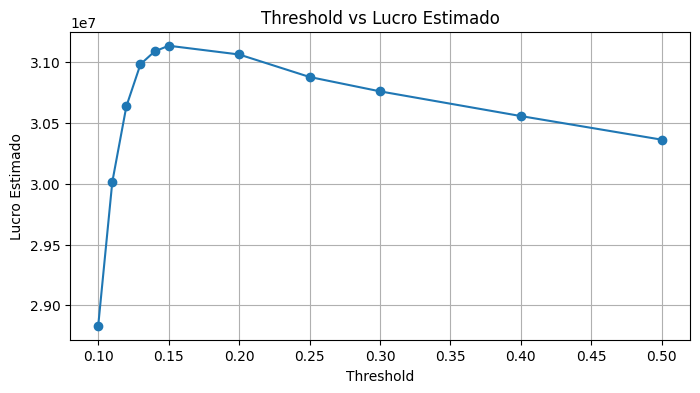

In [28]:
# gráfico - threshold x lucro:
plt.figure(figsize=(8,4))
plt.plot(df_resultados['threshold'], df_resultados['lucro_estimado'], marker='o')
plt.xlabel('Threshold')
plt.ylabel('Lucro Estimado')
plt.title('Threshold vs Lucro Estimado')
plt.grid(True)
plt.show()

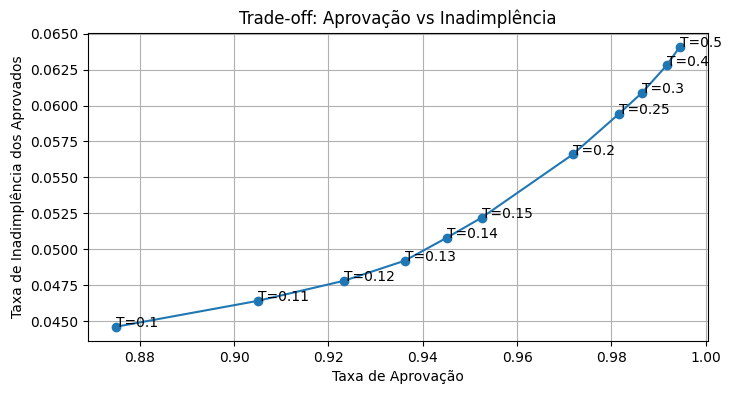

In [29]:
plt.figure(figsize=(8,4))
plt.plot(df_resultados['taxa_aprovacao'], df_resultados['taxa_inadimplencia_aprovados'], marker='o')

for i, row in df_resultados.iterrows():
    plt.text(row['taxa_aprovacao'], row['taxa_inadimplencia_aprovados'], f"T={row['threshold']}")

plt.xlabel('Taxa de Aprovação')
plt.ylabel('Taxa de Inadimplência dos Aprovados')
plt.title('Trade-off: Aprovação vs Inadimplência')
plt.grid(True)
plt.show()

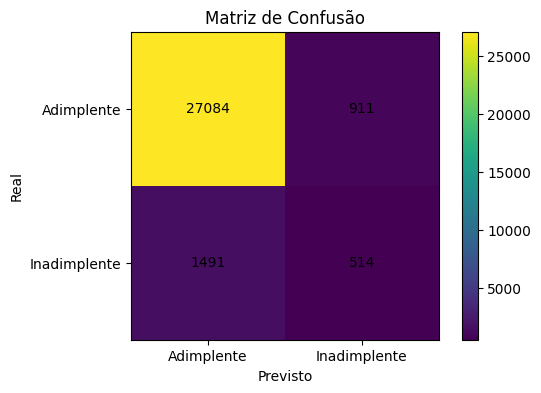

In [35]:
# matriz de confusão:
threshold = 0.15

y_pred_class = (y_pred > threshold).astype(int)
cm = mt.confusion_matrix(y_validation, y_pred_class)

plt.figure(figsize=(6,4))
plt.imshow(cm)
plt.title('Matriz de Confusão')
plt.colorbar()
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.xticks([0,1], ['Adimplente', 'Inadimplente'])
plt.yticks([0,1], ['Adimplente', 'Inadimplente'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center')
plt.show()

## 8.0 Resultados

- Lucro estimado máximo: R\$31.133.400,00 
- Risco esperado (expected loss): R\$9.7M
- Taxa de aprovação: 95.25% correspondendo a 28.575 clientes
- Taxa de inadimplência dentre os aprovados: 5.22%

- Threshold com maior lucro estimado: 0.15
- Recall (inadimplentes): 0.2564
- Precision (inadimplentes): 0.3607
- ROC-AUC Score: 0.7051

- 150.000 clientes totais
- 30.000 clientes avaliados na business performance
- Desses, 27.084 clientes foram true positives (positivos verdadeiros);
- 1.491 clientes foram false positives (falsos positivos);
- 911 clientes foram false negatives (falsos negativos) e
- 514 clientes foram true negatives (negativos verdadeiros)

## 9.0 Conclusão

- Threshold de 0.15 maximiza lucro esperado e reduz perdas mantendo alta taxa de aprovação.
- Embora thresholds mais conservadores reduzam a inadimplência esperada, thresholds excessivamente baixos reduzem 
o lucro devido à rejeição de clientes potencialmente rentáveis. O threshold de 0.15 apresentou o melhor equilíbrio 
entre risco e retorno.

- A recomendação é que o limite da probabilidade de inadimplência seja estabelecido em 15%.